# Test Trained Diffusion Model

This notebook loads a trained diffusion residual model, samples a residual from noise conditioned on a glossy input, reconstructs the diffuse image, and visualises the result against the ground truth.


In [17]:
import os
import sys
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

workspace_root = Path.cwd()
if (workspace_root / "pipeline").exists():
    project_root = workspace_root
elif (workspace_root / "Specular-Highlights" / "pipeline").exists():
    project_root = workspace_root / "Specular-Highlights"
else:
    raise RuntimeError("Could not locate the Specular-Highlights project root from the current working directory.")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from pipeline import Diffuser as diff
from pipeline import difresloader
from pipeline.ResidualLoader import reconstruct_diffuse
from sh_models import d_backbone as Backbone

device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
print("Project root:", project_root)
print("Device:", device)



Project root: /Users/27171653/Desktop/PhD/Highlight-modelling/Specular-Highlights
Device: cpu


In [18]:
# Cell 2: Configuration
project_root = Path(".").resolve()

# Model parameters
model_name = "UNetWithAttention"
depth = 4
image_size = 128
resize_hw = (image_size, image_size)
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
noise_steps = 200  # must match the checkpoint training config in runtraining.py
residual_mode = "additive"
seed = 42
use_ddim = True
skip_steps = 20

# Dataset paths
default_dataset_root = project_root.parent / "PSD_Dataset" / "PSD_Dataset" / "PSD_Train"
dataset_root = Path(os.environ.get("PSD_TRAIN_ROOT", default_dataset_root)).expanduser()
diffuse_dir = dataset_root / "PSD_Train_diffuse"
glossy_dir = dataset_root / "PSD_Train_specular"

if not diffuse_dir.exists() or not glossy_dir.exists():
    raise FileNotFoundError(
        "Could not find PSD dataset folders. "
        f"Expected {diffuse_dir} and {glossy_dir}. "
        "Set PSD_TRAIN_ROOT to the PSD_Train directory if needed."
    )

# Checkpoint selection
checkpoint_strategy = "latest_epoch"  # latest_epoch | lowest_loss | newest_file
checkpoint_hint = model_name
checkpoint_index = 0  # choose from the indexed list printed in Cell 3



Checkpoint exists: False /Users/27171653/Desktop/PhD/Highlight-modelling/Specular-Highlights/models/UNetWithAttention.pth
Diffuse dir exists: True /Users/27171653/Desktop/PhD/Highlight-modelling/PSD_Dataset/PSD_Dataset/PSD_Train/PSD_Train_diffuse
Glossy dir exists: True /Users/27171653/Desktop/PhD/Highlight-modelling/PSD_Dataset/PSD_Dataset/PSD_Train/PSD_Train_specular


In [19]:
# Cell 3: Discover valid checkpoints and choose one by index
import re


def checkpoint_sort_key(path, strategy="latest_epoch"):
    text = str(path)
    epoch_match = re.search(r"epoch[_-](\d+)", text, re.IGNORECASE)
    loss_match = re.search(r"loss[_-]([0-9]*\.?[0-9]+)", text, re.IGNORECASE)

    epoch = int(epoch_match.group(1)) if epoch_match else -1
    loss = float(loss_match.group(1)) if loss_match else float("inf")
    mtime = path.stat().st_mtime

    if strategy == "lowest_loss":
        return (loss, -epoch, -mtime)
    if strategy == "newest_file":
        return (-mtime, -epoch, loss)
    return (-epoch, loss, -mtime)


def extract_model_name(path: Path):
    match = re.search(r"Uncert(.+?)_epoch_", str(path))
    if match:
        return match.group(1)
    return None


def discover_checkpoints(root, model_hint=None, strategy="latest_epoch"):
    patterns = [
        "checkpoints/**/model.pth",
        "models/**/*.pth",
    ]

    candidates = []
    for pattern in patterns:
        candidates.extend(root.glob(pattern))

    candidates = [p for p in candidates if p.is_file()]

    if model_hint:
        exact = [p for p in candidates if extract_model_name(p) == model_hint]
        if exact:
            candidates = exact
        else:
            hinted = [p for p in candidates if model_hint.lower() in str(p).lower()]
            if hinted:
                candidates = hinted

    if not candidates:
        raise FileNotFoundError(f"No checkpoints found under {root}")

    return sorted(candidates, key=lambda p: checkpoint_sort_key(p, strategy))


available_checkpoints = discover_checkpoints(
    project_root, model_hint=checkpoint_hint, strategy=checkpoint_strategy
)

if checkpoint_index < 0 or checkpoint_index >= len(available_checkpoints):
    raise IndexError(
        f"checkpoint_index={checkpoint_index} is out of range for {len(available_checkpoints)} checkpoints"
    )

checkpoint_path = available_checkpoints[checkpoint_index]

print(f"Using device: {device}")
print(f"Checkpoint strategy: {checkpoint_strategy}")
print(f"Checkpoint hint: {checkpoint_hint}")
print("Available checkpoints:")
for idx, path in enumerate(available_checkpoints):
    selected = " <= selected" if idx == checkpoint_index else ""
    print(f"[{idx}] {path}{selected}")

print()
print(f"Selected checkpoint: {checkpoint_path}")



checkpoints/new/UncertUNetWithAttention_epoch_200_TParam_e_loss_0.2243/model.pth
checkpoints/new/UncertUNetWithAttention_epoch_400_TParam_e_loss_0.1557/model.pth
checkpoints/new/UncertUNetWithAttention_epoch_600_TParam_e_loss_0.1202/model.pth
checkpoints/new/UncertUNetWithAttention_epoch_800_TParam_e_loss_0.1183/model.pth


In [ ]:
# Cell 4: Checkpoint note
print("This notebook supports image-space UNet checkpoints only.")



In [21]:
def set_seed(seed_value: int) -> None:
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_value)


def load_model(checkpoint: Path):
    model = Backbone.UNetWithAttention(depth=depth).to(device)
    checkpoint_obj = torch.load(checkpoint, map_location="cpu")
    state_dict = checkpoint_obj["model_state_dict"] if isinstance(checkpoint_obj, dict) and "model_state_dict" in checkpoint_obj else checkpoint_obj
    model.load_state_dict(state_dict)
    model.eval()
    return model


def make_dataset():
    dataset, loader = difresloader.make_diffusion_dataloader(
        diffuse_dir=diffuse_dir,
        glossy_dir=glossy_dir,
        batch_size=1,
        shuffle=False,
        num_workers=0,
        resize_hw=resize_hw,
        residual_mode=residual_mode,
        augment=False,
    )
    return dataset, loader


def to_hwc(tensor: torch.Tensor):
    return tensor.detach().cpu().permute(1, 2, 0).clamp(0.0, 1.0).numpy()


def residual_for_display(tensor: torch.Tensor):
    tensor = tensor.detach().cpu()
    tensor = tensor - tensor.min()
    tensor = tensor / tensor.max().clamp_min(1e-8)
    return tensor.permute(1, 2, 0).numpy()


def run_inference(sample: dict, model: torch.nn.Module):
    diffuser = diff.CosSchDiffuser(steps=noise_steps, device=device)
    glossy = sample["glossy"].unsqueeze(0).to(device).float()
    set_seed(seed)
    predicted_residual = diffuser.sample_from_noise(
        model,
        glossy,
        show_progress=True,
        ddim=use_ddim,
        skip_steps=skip_steps,
    )[0].detach().cpu()

    predicted_diffuse = reconstruct_diffuse(
        sample["glossy"],
        predicted_residual,
        residual_mode=residual_mode,
    ).clamp(0.0, 1.0)

    error_map = (predicted_diffuse - sample["diffuse"]).abs().mean(dim=0)

    return {
        "predicted_residual": predicted_residual,
        "predicted_diffuse": predicted_diffuse,
        "error_map": error_map,
    }


def show_result(sample: dict, result: dict) -> None:
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))

    axes[0, 0].imshow(to_hwc(sample["glossy"]))
    axes[0, 0].set_title(f"Glossy\n{sample.get('name', 'sample')}")

    axes[0, 1].imshow(to_hwc(sample["diffuse"]))
    axes[0, 1].set_title("Diffuse (True)")

    axes[0, 2].imshow(residual_for_display(sample["residual"]))
    axes[0, 2].set_title("Residual (True)")

    axes[1, 0].imshow(residual_for_display(result["predicted_residual"]))
    axes[1, 0].set_title("Residual (Pred)")

    axes[1, 1].imshow(to_hwc(result["predicted_diffuse"]))
    axes[1, 1].set_title("Diffuse (Pred)")

    axes[1, 2].imshow(result["error_map"].detach().cpu(), cmap="inferno")
    axes[1, 2].set_title("Mean Abs Error")

    for ax in axes.flat:
        ax.axis("off")

    plt.tight_layout()
    plt.show()



Dataset size: 361


 99%|█████████▉| 99/100 [00:36<00:00,  2.69it/s]


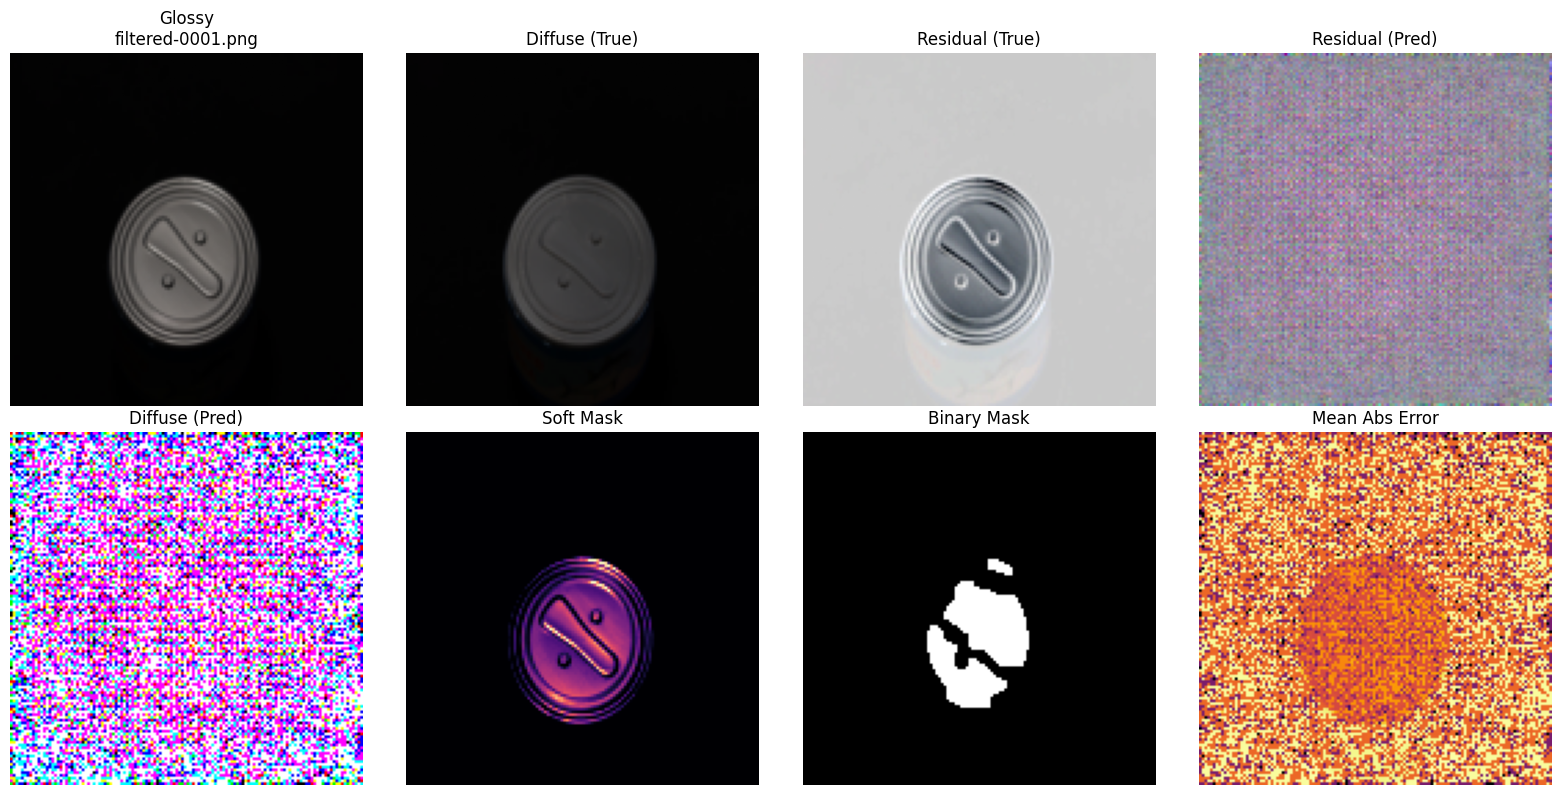

In [22]:
# Cell 6: Load model and dataset
model = load_model(checkpoint_path)
dataset, _ = make_dataset()
print(f"Loaded checkpoint: {checkpoint_path}")
print(f"Dataset size: {len(dataset)}")



 99%|█████████▉| 99/100 [00:30<00:00,  3.24it/s]


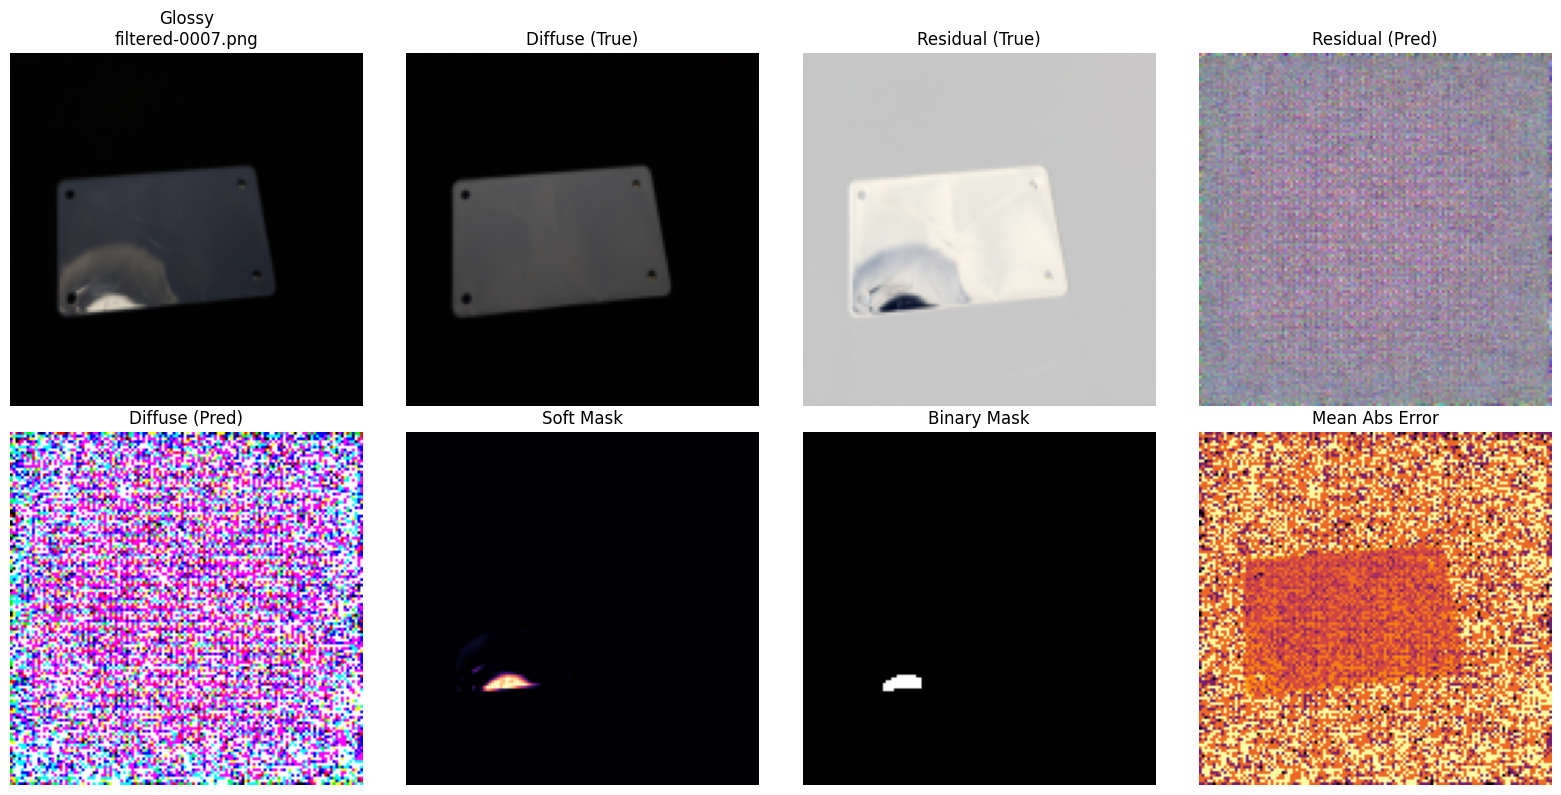

In [25]:
# Change sample_index and rerun this cell to inspect another item.
sample_index = 6
sample = dataset[sample_index]
result = run_inference(sample, model)
show_result(sample, result)

